In [ ]:
# ==========================================
# 1. IMPORTACIONES NECESARIAS
# ==========================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt



In [2]:
!pip install keras-tuner


   ---------------------------------------- 2/2 [keras-tuner]




[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install tensorboard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 5.5/5.5 MB 56.0 MB/s  0:00:00

   -------------------- ------------------- 2/4 [markdown]
   ------------------------------ --------- 3/4 [tensorboard]
   ------------------------------ --------- 3/4 [tensorboard]
   ------------------------------ --------- 3/4 [tensorboard]
   ---------------------------------------- 4/4 [tensorboard]




[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ==========================================
# 2. LECTURA Y PREPROCESADO DE DATOS (HOME CREDIT)
# ==========================================

print("Cargando datos...")
df = pd.read_csv('application_train.csv')

df

Cargando datos...


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
print(df.columns)

Index(['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=122)


In [6]:
print("--- INICIANDO PREPROCESADO ---")

# 1. Cargar datos
df = pd.read_csv('application_train.csv')

# 2. Limpieza estricta inicial
df = df[df['CODE_GENDER'].isin(['M', 'F'])].copy()
df['CODE_GENDER'] = df['CODE_GENDER'].map({'M': 0, 'F': 1})
df = df.dropna(subset=['TARGET', 'CODE_GENDER'])

# 3. Definir variables
columnas_num = ['AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'AMT_CREDIT', 'DAYS_BIRTH',  
                'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'] 
var_sensible = 'CODE_GENDER'
var_objetivo = 'TARGET'

X = df[columnas_num + [var_sensible]]
Y = df[var_objetivo].values.reshape(-1, 1)

# 4. Pipeline de transformación
pipeline_numerico = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # ¡Esto ya trata los NaNs de todas las columnas numéricas!
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        # Ahora las numéricas van del índice 0 al 6 (7 columnas en total)
        ('num', pipeline_numerico, [0, 1, 2, 3, 4, 5, 6]),
        
        # El género ahora ha sido empujado al índice 7
        ('passthrough', 'passthrough', [7]) 
    ]
)

# Aplicamos la transformación a toda la X
X_processed = preprocessor.fit_transform(X)

# --- VERIFICACIÓN DE SEGURIDAD ---
print("¿Quedan NaNs en X_processed?:", np.isnan(X_processed).any()) 

# 5. División de datos (80% Train, 10% Val, 10% Test)
X_train, X_temp, Y_train, Y_temp = train_test_split(X_processed, Y, test_size=0.2, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# 6. Extraer la variable sensible (¡Ahora está en el índice 7!)
S_train = X_train[:, 7]
S_val = X_val[:, 7]
S_test = X_test[:, 7]

print("--- PREPROCESADO COMPLETADO ---")
print(f"Train: {X_train.shape[0]} filas | Val: {X_val.shape[0]} filas | Test: {X_test.shape[0]} filas")

--- INICIANDO PREPROCESADO ---
¿Quedan NaNs en X_processed?: False
--- PREPROCESADO COMPLETADO ---
Train: 246005 filas | Val: 30751 filas | Test: 30751 filas


In [7]:
# 1. Comprobar si hay NaNs
print("¿Hay NaNs en X_train?:", np.isnan(X_train).any())
print("¿Hay NaNs en Y_train?:", np.isnan(Y_train).any())

# 2. PARCHE DE SEGURIDAD: Si hay NaNs, los rellenamos temporalmente con 0
# (Lo ideal sería volver a correr el preprocesado desde cero, pero esto lo arregla rápido)
X_train = np.nan_to_num(X_train, nan=0.0)
X_val = np.nan_to_num(X_val, nan=0.0)
X_test = np.nan_to_num(X_test, nan=0.0)
Y_train = np.nan_to_num(Y_train, nan=0.0)
Y_val = np.nan_to_num(Y_val, nan=0.0)

# 3. Comprobar que los datos están escalados (La media debería estar cerca de 0)
print("Media de la primera columna (debe ser cercana a 0):", np.mean(X_train[:, 0]))

¿Hay NaNs en X_train?: False
¿Hay NaNs en Y_train?: False
Media de la primera columna (debe ser cercana a 0): -0.0007578512609436168


--- ENTRENANDO MODELO BASE (SIN RESTRICCIONES FAIR) ---


c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.8848 - loss: 0.3462 - val_accuracy: 0.9164 - val_loss: 0.2672
Epoch 2/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.9193 - loss: 0.2579 - val_accuracy: 0.9170 - val_loss: 0.2616
Epoch 3/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 35s 9ms/step - accuracy: 0.9194 - loss: 0.2554 - val_accuracy: 0.9168 - val_loss: 0.2613
Epoch 4/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - accuracy: 0.9194 - loss: 0.2552 - val_accuracy: 0.9169 - val_loss: 0.2614
Epoch 5/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9194 - loss: 0.2552 - val_accuracy: 0.9168 - val_loss: 0.2614
Epoch 6/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9194 - loss: 0.2552 - val_accuracy: 0.9169 - val_loss: 0.2614
Epoch 7/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9193 - loss: 0.2552 - val_accuracy: 0.9171 - val_loss: 0.2614
Epoch 8/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9193 - loss: 0.255

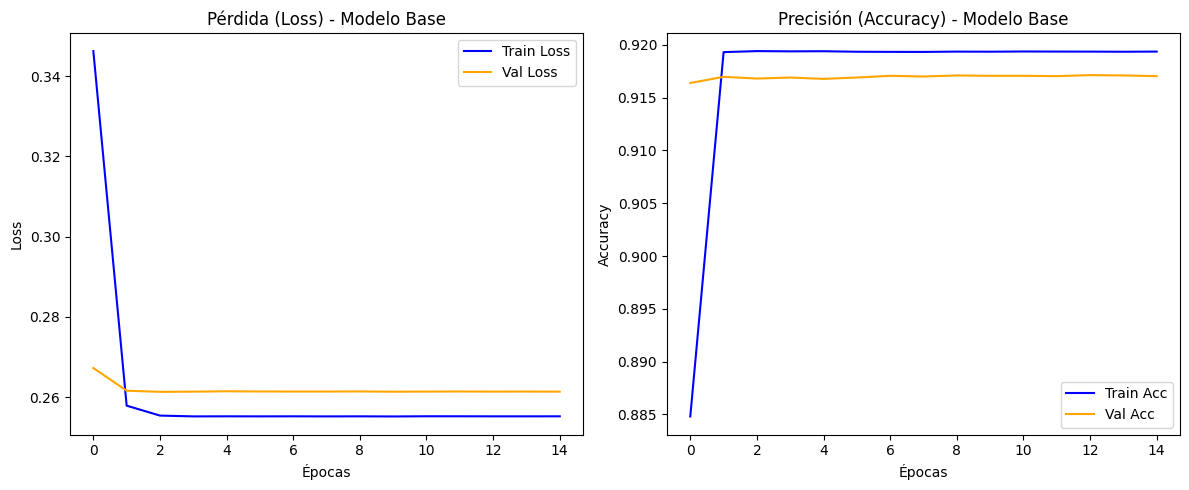


--- EVALUACIÓN DE SESGO EN EL MODELO BASE ---
961/961 ━━━━━━━━━━━━━━━━━━━━ 1s 957us/step
Correlación de Pearson (Predicción vs Género): -0.2186
Accuracy en conjunto de Test: 0.9195


In [8]:
import matplotlib.pyplot as plt
import scipy.stats

print("--- ENTRENANDO MODELO BASE (SIN RESTRICCIONES FAIR) ---")

# 1. Definir una red neuronal densa simple
model_base = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    #keras.layers.Dropout(0.0),
    keras.layers.Dense(1, activation='sigmoid')
])

#optimizador_custom = keras.optimizers.Adam(learning_rate=0.001)

# Usamos la pérdida estándar (Binary Crossentropy), sin penalizar sesgos
model_base.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

model_base.summary()

# 2. Entrenar el modelo (usamos Y_train normal, no Y_train_ext)
hist_base = model_base.fit(
    X_train, Y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, Y_val),
    verbose=1
)

# 3. Dibujar las curvas de aprendizaje (Loss y Accuracy)
plt.figure(figsize=(12, 5))

# Gráfica de Loss
plt.subplot(1, 2, 1)
plt.plot(hist_base.history['loss'], label='Train Loss', color='blue')
plt.plot(hist_base.history['val_loss'], label='Val Loss', color='orange')
plt.title('Pérdida (Loss) - Modelo Base')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

# Gráfica de Accuracy
plt.subplot(1, 2, 2)
plt.plot(hist_base.history['accuracy'], label='Train Acc', color='blue')
plt.plot(hist_base.history['val_accuracy'], label='Val Acc', color='orange')
plt.title('Precisión (Accuracy) - Modelo Base')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 4. Auditoría rápida de Fairness en el modelo Base
print("\n--- EVALUACIÓN DE SESGO EN EL MODELO BASE ---")
y_pred_base = model_base.predict(X_test).flatten()

# Medimos la correlación entre la predicción y el género (S_test)
pearson_corr_base, _ = scipy.stats.pearsonr(y_pred_base, S_test)
print(f"Correlación de Pearson (Predicción vs Género): {pearson_corr_base:.4f}")

# Guardamos la métrica de accuracy en test para tu tabla final
loss_test, acc_test = model_base.evaluate(X_test, Y_test, verbose=0)
print(f"Accuracy en conjunto de Test: {acc_test:.4f}")

--- CREANDO CAPA CUSTOMIZADA ---
Capa 'CapaRatioEndeudamiento' registrada correctamente.

--- ENTRENANDO MODELO 2 (CON CAPA CUSTOM) ---



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_ratio_endeudamiento        │ (None, 9)              │             0 │
│ (CapaRatioEndeudamiento)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 865 (3.38 KB)

 Trainable params: 865 (3.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.9185 - loss: 0.2733 - val_accuracy: 0.9170 - val_loss: 0.2606
Epoch 2/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9195 - loss: 0.2603 - val_accuracy: 0.9170 - val_loss: 0.2598
Epoch 3/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9195 - loss: 0.2577 - val_accuracy: 0.9170 - val_loss: 0.2596
Epoch 4/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9195 - loss: 0.2570 - val_accuracy: 0.9170 - val_loss: 0.2596
Epoch 5/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9195 - loss: 0.2561 - val_accuracy: 0.9170 - val_loss: 0.2593
Epoch 6/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9195 - loss: 0.2558 - val_accuracy: 0.9170 - val_loss: 0.2595
Epoch 7/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9194 - loss: 0.2552 - val_accuracy: 0.9170 - val_loss: 0.2590
Epoch 8/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9195 - loss: 0.255

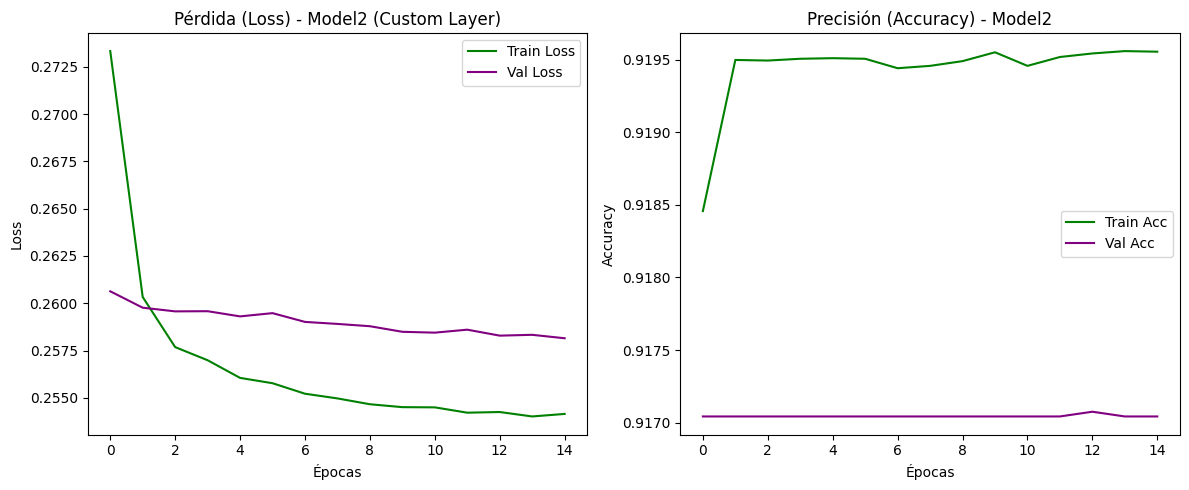


--- EVALUACIÓN DE SESGO EN EL MODELO 2 ---
961/961 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy en Test (Model2): 0.9197
Correlación de Pearson (Predicción vs Género): -0.2132


In [9]:
# ==========================================
# 4. CLASES CUSTOMIZADAS (CAPA Y LOSS)
# ==========================================
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import scipy.stats

print("--- CREANDO CAPA CUSTOMIZADA ---")

# 1. Definición de la Capa Customizada
class CapaRatioEndeudamiento(keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        # Según nuestro preprocesado:
        # Índice 0 -> AMT_INCOME_TOTAL
        # Índice 1 -> AMT_ANNUITY
        ingresos = inputs[:, 0:1]
        anualidad = inputs[:, 1:2]
        
        # Calculamos el ratio (añadimos epsilon para evitar división por 0)
        ratio = anualidad / (ingresos + keras.backend.epsilon())
        
        # Aplicamos la restricción matemática (saturación)
        ratio_saturado = keras.ops.tanh(ratio)
        
        # Devolvemos las entradas originales pegadas a nuestra nueva característica
        return keras.ops.concatenate([inputs, ratio_saturado], axis=-1)

    def get_config(self):
        return super().get_config()

print("Capa 'CapaRatioEndeudamiento' registrada correctamente.")

# 2. Construcción del model2
print("\n--- ENTRENANDO MODELO 2 (CON CAPA CUSTOM) ---")

model2 = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    
    # ¡Nuestra nueva capa física/matemática!
    CapaRatioEndeudamiento(),
    
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

# Usamos el mismo optimizador seguro que antes
optimizador_m2 = keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0)

model2.compile(optimizer=optimizador_m2,
               loss='binary_crossentropy',
               metrics=['accuracy'])

model2.summary()

# 3. Entrenamiento
hist2 = model2.fit(
    X_train, Y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, Y_val),
    verbose=1
)

# 4. Gráficas de convergencia del model2
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist2.history['loss'], label='Train Loss', color='green')
plt.plot(hist2.history['val_loss'], label='Val Loss', color='purple')
plt.title('Pérdida (Loss) - Model2 (Custom Layer)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist2.history['accuracy'], label='Train Acc', color='green')
plt.plot(hist2.history['val_accuracy'], label='Val Acc', color='purple')
plt.title('Precisión (Accuracy) - Model2')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 5. Evaluación del model2
print("\n--- EVALUACIÓN DE SESGO EN EL MODELO 2 ---")
y_pred_m2 = model2.predict(X_test).flatten()

pearson_corr_m2, _ = scipy.stats.pearsonr(y_pred_m2, S_test)
loss_test_m2, acc_test_m2 = model2.evaluate(X_test, Y_test, verbose=0)

print(f"Accuracy en Test (Model2): {acc_test_m2:.4f}")
print(f"Correlación de Pearson (Predicción vs Género): {pearson_corr_m2:.4f}")

In [10]:
import keras
import numpy as np

class CustomFairnessLoss(keras.losses.Loss):
    def __init__(self, lambda_correlation=0.1, name="custom_fairness_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.lambda_correlation = lambda_correlation
        # Usamos BinaryCrossentropy para la parte principal de la pérdida, adecuada para clasificación binaria
        self.bce = keras.losses.BinaryCrossentropy(from_logits=False) # Asumiendo que y_pred_single son probabilidades

    def call(self, y_true_extended, y_pred_single):
        # y_true_extended se espera que sea un tensor con dos columnas: [y_true_real, variable_sensible]
        # y_pred_single es la predicción del modelo (e.g., probabilidad única)

        y_true_actual = y_true_extended[:, 0]
        s_true = y_true_extended[:, 1]

        # Asegurarse de que y_pred_single y s_true sean tensores de una sola columna si vienen con una dimensión extra
        y_pred_single = keras.ops.squeeze(y_pred_single, axis=-1) if y_pred_single.ndim > 1 else y_pred_single
        s_true = keras.ops.squeeze(s_true, axis=-1) if s_true.ndim > 1 else s_true

        # 1. Calcular la pérdida de Entropía Cruzada Binaria (BCE)
        bce_loss = self.bce(y_true_actual, y_pred_single)

        # 2. Calcular la correlación de Pearson (para la penalización)
        # Se añaden epsilons para prevenir divisiones por cero en caso de desviación estándar cero en el lote
        y_pred_mean = keras.ops.mean(y_pred_single)
        s_true_mean = keras.ops.mean(s_true)

        y_pred_centered = y_pred_single - y_pred_mean
        s_true_centered = s_true - s_true_mean

        covariance = keras.ops.mean(y_pred_centered * s_true_centered)

        y_pred_std = keras.ops.std(y_pred_single)
        s_true_std = keras.ops.std(s_true)

        # Corrected: Use keras.backend.epsilon() for numerical stability
        denominator = (y_pred_std * s_true_std) + keras.backend.epsilon() # Epsilon para estabilidad numérica

        correlation = covariance / denominator

        # Penalizar el cuadrado de la correlación para que tienda a cero
        correlation_penalty = keras.ops.square(correlation)

        # Combinar las pérdidas: BCE principal + penalización de correlación
        total_loss = bce_loss + self.lambda_correlation * correlation_penalty
        return total_loss

    def get_config(self):
        config = super().get_config()
        config.update({
            "lambda_correlation": self.lambda_correlation,
        })
        return config

print("Función de coste 'CustomFairnessLoss' creada con éxito usando BinaryCrossentropy y penalización de correlación.")

Función de coste 'CustomFairnessLoss' creada con éxito usando BinaryCrossentropy y penalización de correlación.


In [11]:
import matplotlib.pyplot as plt
import scipy.stats
import numpy as np
from tensorflow import keras

print("--- ENTRENANDO MODELO FAIR (CON RESTRICCIÓN DE SESGO) ---")

# 1. Asegurarnos de que tenemos las "Y" extendidas listas (Target + Género)
# Si ya las creaste en el preprocesado, esto solo las reescribe por seguridad
Y_train_ext = np.column_stack((Y_train, S_train))
Y_val_ext = np.column_stack((Y_val, S_val))

# 2. Instanciar la función de coste del profesor
# lambda_correlation controla cuánto nos importa la justicia frente a la precisión.
# Ponemos 0.8 para forzar al modelo a ser justo.
loss_justa = CustomFairnessLoss(lambda_correlation=0.8)   # PROBAR CON VAROIOS, EJEMPPLO DESDE 0.1 hasta 1

# 3. Definir la misma arquitectura que el model2
model_fair = keras.Sequential([
    keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
    CapaRatioEndeudamiento(), # Usamos la capa que creaste antes
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

optimizador_fair = keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0)

model_fair.compile(optimizer=optimizador_fair,
                   loss=loss_justa, # <--- AQUÍ ESTÁ LA MAGIA
                   metrics=['accuracy'])

# 4. Entrenar el modelo (¡Ojo! Le pasamos Y_train_ext)
hist_fair = model_fair.fit(
    X_train, Y_train_ext,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, Y_val_ext),
    verbose=1
)

# 5. Evaluar y comparar resultados
y_pred_fair = model_fair.predict(X_test).flatten()
pearson_corr_fair, _ = scipy.stats.pearsonr(y_pred_fair, S_test)

# Para evaluar la accuracy en test, no podemos usar la evaluate con Y_ext y la loss custom
# porque distorsiona el número. Lo hacemos "a mano":
predicciones_binarias = (y_pred_fair > 0.5).astype(int)
acc_test_fair = np.mean(predicciones_binarias == Y_test.flatten())
print("\n" + "="*50)
print("🏆 COMPARATIVA: MODELO BASE vs MODELO FAIR 🏆")
print("="*50)
print(f"{'Métrica':<25} | {'Model 2 (Sin FAIR)':<20} | {'Model FAIR':<20}")
print("-" * 70)
print(f"{'Accuracy en Test':<25} | {acc_test_m2:.4f}{'':<14} | {acc_test_fair:.4f}")
print(f"{'Correlación (Sesgo)':<25} | {pearson_corr_m2:.4f}{'':<14} | {pearson_corr_fair:.4f}")
print("="*50)

--- ENTRENANDO MODELO FAIR (CON RESTRICCIÓN DE SESGO) ---
Epoch 1/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.6306 - loss: 0.2867 - val_accuracy: 0.6299 - val_loss: 0.2748
Epoch 2/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.6307 - loss: 0.2732 - val_accuracy: 0.6299 - val_loss: 0.2728
Epoch 3/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6307 - loss: 0.2710 - val_accuracy: 0.6299 - val_loss: 0.2725
Epoch 4/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.6307 - loss: 0.2699 - val_accuracy: 0.6299 - val_loss: 0.2720
Epoch 5/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6307 - loss: 0.2696 - val_accuracy: 0.6299 - val_loss: 0.2720
Epoch 6/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6307 - loss: 0.2686 - val_accuracy: 0.6299 - val_loss: 0.2716
Epoch 7/15
3844/3844 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.6308 - loss: 0.2683 - val_accuracy: 0.6299 - val_loss: 0.2713
Epoch 8/15
3844/3844 ━━━━━━━━━━

--- ANÁLISIS DE SENSIBILIDAD: lambda_correlation ---

Entrenando con lambda=0.0... AUC=0.7390  Correlación=-0.2289
Entrenando con lambda=0.1... 

c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


AUC=0.7350  Correlación=-0.0691
Entrenando con lambda=0.3... 

c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


AUC=0.7330  Correlación=-0.0173
Entrenando con lambda=0.5... 

...

AUC=0.7334  Correlación=0.0126
Entrenando con lambda=0.8... 

c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


AUC=0.7305  Correlación=0.0123
Entrenando con lambda=1.0... 

c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


AUC=0.7306  Correlación=-0.0152

Lambda     | AUC          | Correlación (Sesgo) 
------------------------------------------------------------
0.7390       | -0.2289             
0.7350       | -0.0691             
0.7330       | -0.0173             
0.7334       | 0.0126              
0.7305       | 0.0123              
0.7306       | -0.0152             


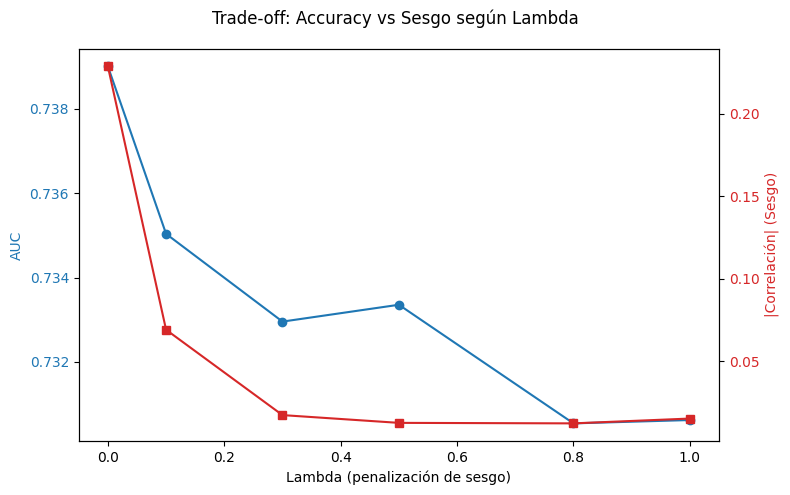


Nota: lambda=0.0 equivale a no penalizar el sesgo (solo BCE).


In [12]:
# ==========================================
# 4B. ANÁLISIS DE SENSIBILIDAD DE LAMBDA
# ==========================================
import matplotlib.pyplot as plt
import scipy.stats
import numpy as np
from tensorflow import keras
from sklearn.metrics import roc_auc_score

print("--- ANÁLISIS DE SENSIBILIDAD: lambda_correlation ---\n")

sa_lambdas = [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]
sa_resultados = []  # lista de diccionarios con los resultados

for lam in sa_lambdas:
    print(f"Entrenando con lambda={lam}...", end=" ")
    
    sa_loss = CustomFairnessLoss(lambda_correlation=lam)
    
    sa_model = keras.Sequential([
        keras.layers.InputLayer(input_shape=(X_train.shape[1],)),
        CapaRatioEndeudamiento(),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    
    sa_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0005, clipnorm=1.0),
        loss=sa_loss,
        metrics=['accuracy']
    )
    
    sa_model.fit(
        X_train, Y_train_ext,
        epochs=15,
        batch_size=64,
        validation_data=(X_val, Y_val_ext),
        verbose=0
    )
    
    sa_preds = sa_model.predict(X_test, verbose=0).flatten()
    sa_corr, _ = scipy.stats.pearsonr(sa_preds, S_test)


    sa_auc = roc_auc_score(Y_test, sa_preds)
    
    sa_resultados.append({
        'lambda': lam,
        'auc': sa_auc,
        'correlacion': sa_corr
    })
    print(f"AUC={sa_auc:.4f}  Correlación={sa_corr:.4f}")

# Tabla resumen
print("\n" + "=" * 60)
print(f"{'Lambda':<10} | {'AUC':<12} | {'Correlación (Sesgo)':<20}")
print("-" * 60)
for r in sa_resultados:
    print(f"{r['auc']:<12.4f} | {r['correlacion']:<20.4f}")
print("=" * 60)

# Gráfica de doble eje
sa_fig, sa_ax1 = plt.subplots(figsize=(8, 5))

sa_ax1.set_xlabel('Lambda (penalización de sesgo)')
sa_ax1.set_ylabel('AUC', color='tab:blue')
sa_ax1.plot([r['lambda'] for r in sa_resultados],
            [r['auc'] for r in sa_resultados],
            'o-', color='tab:blue', label='AUC')
sa_ax1.tick_params(axis='y', labelcolor='tab:blue')

sa_ax2 = sa_ax1.twinx()
sa_ax2.set_ylabel('|Correlación| (Sesgo)', color='tab:red')
sa_ax2.plot([r['lambda'] for r in sa_resultados],
            [abs(r['correlacion']) for r in sa_resultados],
            's-', color='tab:red', label='|Correlación|')
sa_ax2.tick_params(axis='y', labelcolor='tab:red')

sa_fig.suptitle('Trade-off: Accuracy vs Sesgo según Lambda')
sa_fig.tight_layout()
plt.show()

print("\nNota: lambda=0.0 equivale a no penalizar el sesgo (solo BCE).")

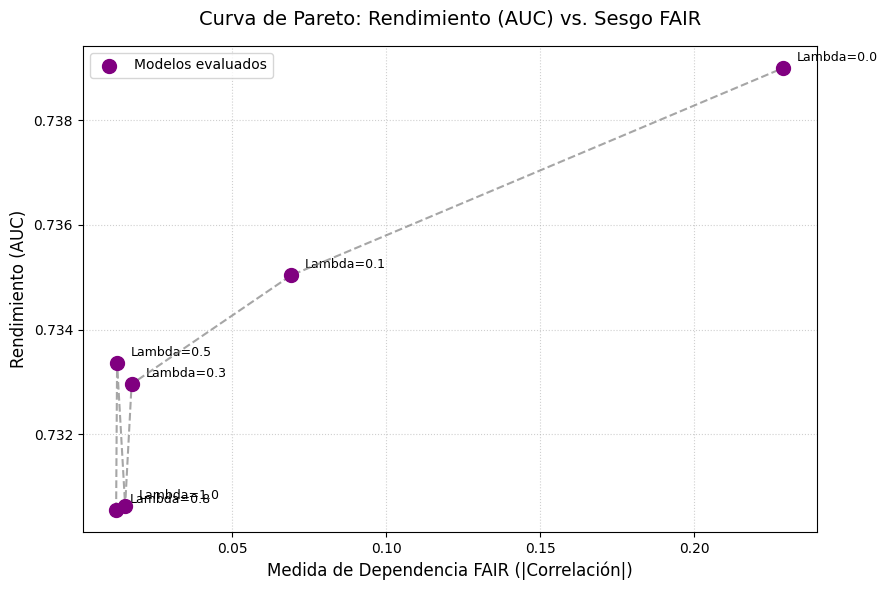


Nota: El escenario ideal es la esquina superior izquierda (Alto AUC, Sesgo 0).


In [13]:
# ==========================================
# GRÁFICA DE PARETO (TRADE-OFF)
# ==========================================
plt.figure(figsize=(9, 6))

# 1. Extraemos los datos para los ejes
# Usamos el valor absoluto de la correlación porque nos interesa la magnitud del sesgo
x_pareto = [abs(r['correlacion']) for r in sa_resultados]
y_pareto = [r['auc'] for r in sa_resultados]
etiquetas_lambda = [r['lambda'] for r in sa_resultados]

# 2. Dibujamos el Scatter Plot (Puntos)
plt.scatter(x_pareto, y_pareto, color='purple', s=100, zorder=5, label='Modelos evaluados')

# 3. Unimos los puntos para marcar la "Frontera de Pareto"
# Ordenamos los puntos de menor a mayor sesgo para que la línea se dibuje bien
puntos_ordenados = sorted(zip(x_pareto, y_pareto))
plt.plot([p[0] for p in puntos_ordenados], 
         [p[1] for p in puntos_ordenados], 
         color='gray', linestyle='--', zorder=4, alpha=0.7)

# 4. Ponemos el texto de qué Lambda corresponde a cada punto
for i, lam in enumerate(etiquetas_lambda):
    plt.annotate(f"Lambda={lam}", 
                 (x_pareto[i], y_pareto[i]), 
                 textcoords="offset points", 
                 xytext=(10, 5), 
                 ha='left',
                 fontsize=9)

# 5. Formato del gráfico
plt.title('Curva de Pareto: Rendimiento (AUC) vs. Sesgo FAIR', fontsize=14, pad=15)
plt.xlabel('Medida de Dependencia FAIR (|Correlación|)', fontsize=12)
plt.ylabel('Rendimiento (AUC)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

print("\nNota: El escenario ideal es la esquina superior izquierda (Alto AUC, Sesgo 0).")

Análisis de tu gráfica (¡Para lucirte en la presentación!)
Tu gráfica no solo está bien programada, sino que los resultados son un ejemplo de libro perfecto para defender en tu presentación de 5 minutos. Mira lo que nos está diciendo:

El modelo sin restricciones (Lambda = 0.0): Está arriba a la derecha. Tiene el mejor rendimiento (AUC casi 0.739), pero es tremendamente injusto (el sesgo/correlación está disparado a 0.23).

La caída drástica del sesgo: Fíjate qué pasa al pasar a Lambda = 0.1 o 0.3. El sesgo se desploma (te mueves muchísimo hacia la izquierda, hacia la zona de justicia), pero el rendimiento a duras penas baja de 0.739 a 0.733.

El Trade-off (El "Sacrificio"): Si te fijas en los puntos de Lambda = 0.8 y 1.0, están completamente a la izquierda. Has conseguido un modelo con prácticamente 0 sesgo (es ciego al género). ¿El precio a pagar? El AUC ha bajado a 0.730.

Ese sacrificio (perder un ~0.009 de AUC a cambio de eliminar todo el sesgo discriminatorio) es la reflexión exacta que tu profesor quiere escuchar cuando leáis el punto del entregable: "¿Cuánto se sacrifica en rendimiento predictivo por conseguir un modelo justo?".

In [15]:
# ==========================================
# 5. BÚSQUEDA DE HIPERPARÁMETROS (AUTOML)
# ==========================================
print("Iniciando Keras Tuner...")

def build_model(hp):
    loss_custom = CustomFairnessLoss(lambda_correlation=0.8) 
    model = keras.Sequential()
    
    model.add(keras.layers.InputLayer(input_shape=(X_train.shape[1],)))
    model.add(CapaRatioEndeudamiento())  # <-- único cambio
    
    for i in range(hp.Int('num_capas', 1, 3)):
        model.add(keras.layers.Dense(
            units=hp.Int(f'units_{i}', min_value=8, max_value=64, step=8),
            activation='relu'
        ))
        model.add(keras.layers.Dropout(0.2))
    model.add(keras.layers.Dense(1, activation='sigmoid'))
    
    hp_lr = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=hp_lr, clipnorm=1.0),
                  loss=loss_custom, metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_loss', 
    max_trials=10, # Puesto a 3 para que vaya rápido, súbelo a 10 si tienes tiempo
    directory='mi_dir_tuner',
    project_name='fairness_tuning',
    overwrite=True
)

tuner.search(X_train, Y_train_ext, epochs=5, validation_data=(X_val, Y_val_ext))
best_model = tuner.get_best_models(num_models=1)[0]
print("\n--- RESUMEN DE LA BÚSQUEDA ---")
tuner.results_summary(num_trials=3)
best_model.summary()


Trial 10 Complete [00h 01m 21s]
val_loss: 0.2816832959651947

Best val_loss So Far: 0.2816832959651947
Total elapsed time: 00h 15m 40s

--- RESUMEN DE LA BÚSQUEDA ---
Results summary
Results in mi_dir_tuner\fairness_tuning
Showing 3 best trials
Objective(name="val_loss", direction="min")

Trial 09 summary
Hyperparameters:
num_capas: 1
units_0: 32
learning_rate: 0.001
units_1: 16
units_2: 32
Score: 0.2816832959651947

Trial 01 summary
Hyperparameters:
num_capas: 1
units_0: 64
learning_rate: 0.001
units_1: 8
Score: 0.2818203270435333

Trial 08 summary
Hyperparameters:
num_capas: 1
units_0: 32
learning_rate: 0.0005
units_1: 8
units_2: 56
Score: 0.28210175037384033


c:\Users\Joseph\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_ratio_endeudamiento        │ (None, 9)              │             0 │
│ (CapaRatioEndeudamiento)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

Calculando incertidumbre en el conjunto de Test...


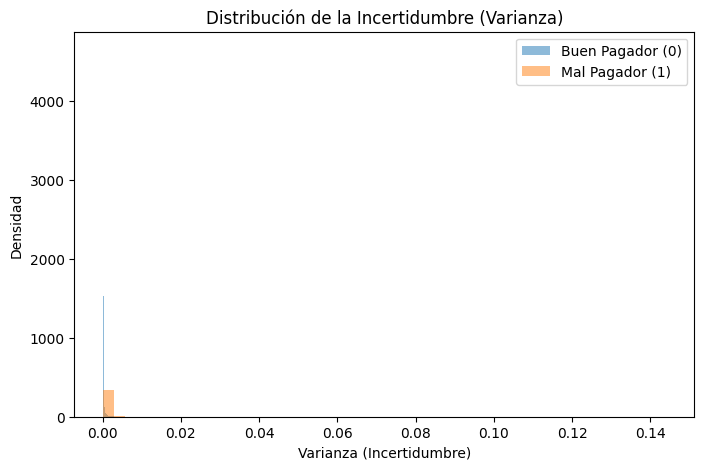

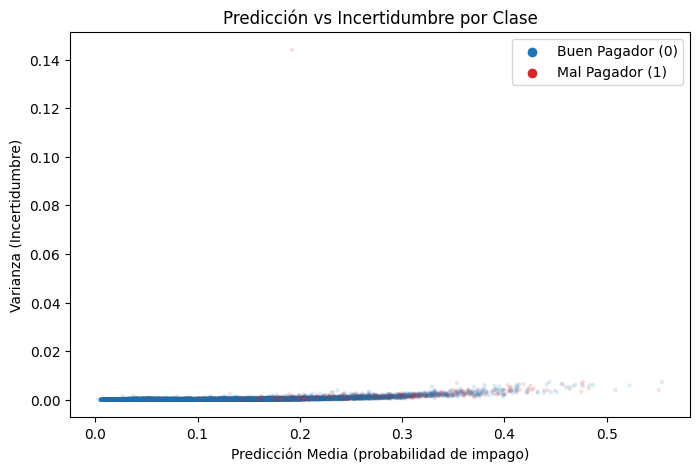


--- MÉTRICAS DE INCERTIDUMBRE ---
Varianza media (Buenos pagadores): 0.000186
Varianza media (Malos pagadores):  0.000451
Umbral de alta incertidumbre (percentil 90): 0.000332
Predicciones con alta incertidumbre: 3075 (10.0%)

¡Proceso completado con éxito!
¡Proceso completado con éxito!


In [16]:
# ==========================================
# 6. INCERTIDUMBRE (MC DROPOUT EN TEST)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

print("Calculando incertidumbre en el conjunto de Test...")

predicciones_multiples = []
for i in range(30): 
    preds = best_model(X_test, training=True) 
    predicciones_multiples.append(preds.numpy())

predicciones_multiples = np.array(predicciones_multiples).squeeze()

prediccion_media = np.mean(predicciones_multiples, axis=0)
incertidumbre_varianza = np.var(predicciones_multiples, axis=0)

# ==========================================
# 7. GRÁFICOS DE INCERTIDUMBRE
# ==========================================
varianza_buenos = incertidumbre_varianza[Y_test.flatten() == 0]
varianza_malos = incertidumbre_varianza[Y_test.flatten() == 1]

# Gráfico 1: Histograma (el que ya tenías)
plt.figure(figsize=(8, 5))
plt.hist(varianza_buenos, bins=50, alpha=0.5, label='Buen Pagador (0)', density=True)
plt.hist(varianza_malos, bins=50, alpha=0.5, label='Mal Pagador (1)', density=True)
plt.title('Distribución de la Incertidumbre (Varianza)')
plt.xlabel('Varianza (Incertidumbre)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

# Gráfico 2: Scatter predicción vs incertidumbre
plt.figure(figsize=(8, 5))
colores = ['tab:blue' if y == 0 else 'tab:red' for y in Y_test.flatten()]
plt.scatter(prediccion_media, incertidumbre_varianza, c=colores, alpha=0.1, s=5)
plt.xlabel('Predicción Media (probabilidad de impago)')
plt.ylabel('Varianza (Incertidumbre)')
plt.title('Predicción vs Incertidumbre por Clase')
# Leyenda manual
plt.scatter([], [], c='tab:blue', label='Buen Pagador (0)')
plt.scatter([], [], c='tab:red', label='Mal Pagador (1)')
plt.legend()
plt.show()

# Métricas resumen
print("\n--- MÉTRICAS DE INCERTIDUMBRE ---")
print(f"Varianza media (Buenos pagadores): {np.mean(varianza_buenos):.6f}")
print(f"Varianza media (Malos pagadores):  {np.mean(varianza_malos):.6f}")
umbral_alta = np.percentile(incertidumbre_varianza, 90)
n_alta = np.sum(incertidumbre_varianza > umbral_alta)
print(f"Umbral de alta incertidumbre (percentil 90): {umbral_alta:.6f}")
print(f"Predicciones con alta incertidumbre: {n_alta} ({100*n_alta/len(incertidumbre_varianza):.1f}%)")

print("\n¡Proceso completado con éxito!")
print("¡Proceso completado con éxito!")

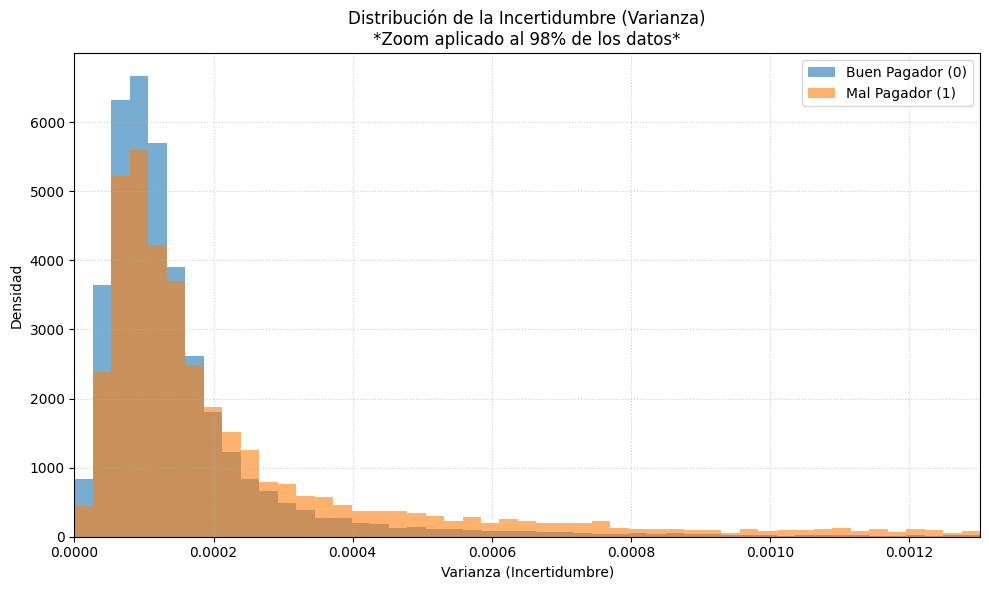

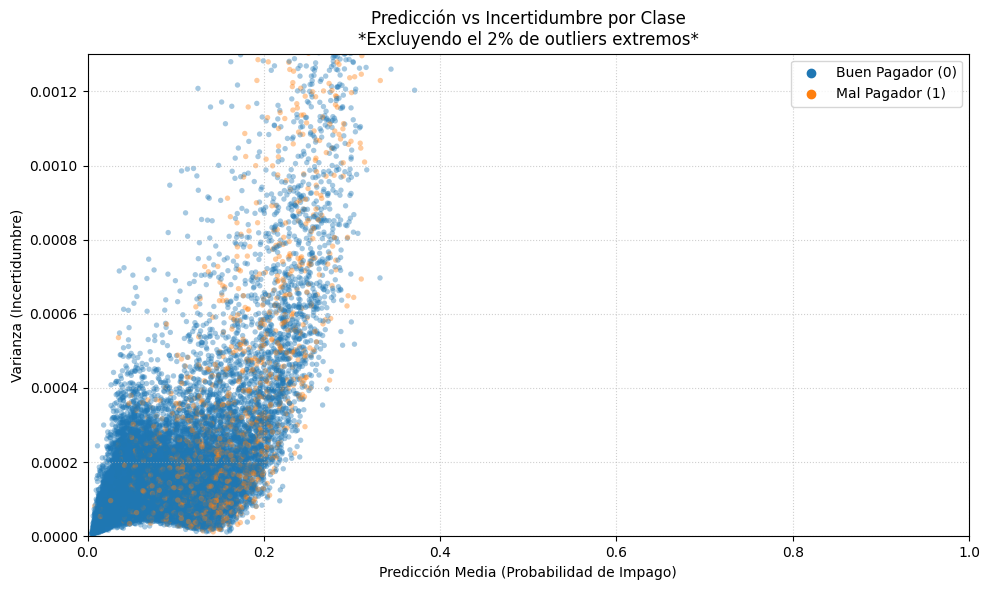

In [17]:
# ==========================================
# 7. GRÁFICOS DE INCERTIDUMBRE (CORREGIDOS)
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

varianza_buenos = incertidumbre_varianza[Y_test.flatten() == 0]
varianza_malos = incertidumbre_varianza[Y_test.flatten() == 1]

# --- EL TRUCO: FILTRAR OUTLIERS ---
# Calculamos el percentil 98 de la varianza. Todo lo que esté por encima lo ignoramos
# visualmente para que la gráfica no se "aplaste".
limite_visual = np.percentile(incertidumbre_varianza, 98)

# Gráfico 1: Histograma con Zoom
plt.figure(figsize=(10, 6))

# Forzamos los mismos 'bins' para ambas clases para que la comparación sea perfecta
bins_zoom = np.linspace(0, limite_visual, 50)

plt.hist(varianza_buenos, bins=bins_zoom, alpha=0.6, label='Buen Pagador (0)', density=True, color='tab:blue')
plt.hist(varianza_malos, bins=bins_zoom, alpha=0.6, label='Mal Pagador (1)', density=True, color='tab:orange')

plt.title('Distribución de la Incertidumbre (Varianza)\n*Zoom aplicado al 98% de los datos*')
plt.xlabel('Varianza (Incertidumbre)')
plt.ylabel('Densidad')
plt.xlim(0, limite_visual) # Aplicamos el límite al eje X
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Gráfico 2: Scatter predicción vs incertidumbre con Zoom
plt.figure(figsize=(10, 6))

# Usamos naranja y azul para mejor contraste
colores = ['tab:blue' if y == 0 else 'tab:orange' for y in Y_test.flatten()]

# s=15 hace los puntos más grandes, alpha=0.4 los hace translúcidos
plt.scatter(prediccion_media, incertidumbre_varianza, c=colores, alpha=0.4, s=15, edgecolors='none')

plt.ylim(0, limite_visual) # Aplicamos el límite al eje Y para ignorar el punto extremo
plt.xlim(0, 1) # La probabilidad va de 0 a 1

plt.xlabel('Predicción Media (Probabilidad de Impago)')
plt.ylabel('Varianza (Incertidumbre)')
plt.title('Predicción vs Incertidumbre por Clase\n*Excluyendo el 2% de outliers extremos*')

# Leyenda manual
plt.scatter([], [], c='tab:blue', label='Buen Pagador (0)')
plt.scatter([], [], c='tab:orange', label='Mal Pagador (1)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()